# Outlier Removal via Z-Score

`02_ML_Roadmap.MD` names two detection methods: IQR (`12_Outlier.ipynb`,
`13_Outlier_Removal_IQR.ipynb`) and **Z-score** — this notebook. Same column
as `13` (`CoapplicantIncome`), on purpose, so the two methods are directly
comparable rather than compared across different data.

**The formula:** `z = (x − mean) / std` — literally "how many standard
deviations away from the mean is this value." This is the exact `σ` axis
from the whiteboard diagram in `12_Outlier.ipynb`: a box plot's `Q1`/`Q3`
lines up with `±0.6745σ`, and its `1.5×IQR` whiskers with `±2.698σ` — Z-score
just measures distance in those same σ units directly, using `|z| > 3` as
the cutoff (the "68-95-99.7 rule": ~99.7% of a truly normal distribution
falls within 3 standard deviations, leaving ~0.3% flagged).

This notebook, in order:
1. Two ways to apply the same threshold (bounds vs. an explicit `z_score`
   column) — both from the original draft, checked against each other.
2. **A real bug in the original draft**, found and fixed — the "be careful
   about what removal actually removes" part.
3. Visualizations: before/after box plot and distribution, plus a new one
   specific to Z-score — the z-values themselves.
4. **IQR vs. Z-score, head-to-head, on the same column** — where they agree,
   where they don't, and why.
5. The final, correctly-cleaned dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv("loans.csv")
dataset.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001001,Male,Yes,0,Not Graduate,No,1686.0,1020,80.0,360.0,1.0,Semiurban,Y
1,LP001002,Male,Yes,0,Not Graduate,No,2437.0,1201,122.0,360.0,1.0,Urban,Y
2,LP001003,Female,No,0,Graduate,No,8313.0,1065,319.0,360.0,1.0,Urban,Y


In [3]:
dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               6
Dependents           15
Education             9
Self_Employed        32
ApplicantIncome       2
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     21
Credit_History       50
Property_Area         9
Loan_Status           0
dtype: int64

`CoapplicantIncome` has 0 missing values — no imputation needed before this one, unlike most other columns here.

In [4]:
dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,616.000000,618.000000,596.000000,597.000000,568.000000
mean,4730.256494,1385.077670,223.031879,312.723618,0.836268
std,2180.942773,1611.760337,93.055097,89.102680,0.370359
min,1500.000000,0.000000,40.000000,36.000000,0.000000
25%,3160.500000,0.000000,152.000000,300.000000,1.000000
50%,4325.000000,1089.000000,208.500000,360.000000,1.000000
75%,5810.750000,2217.750000,282.000000,360.000000,1.000000
max,16981.000000,10288.000000,480.000000,360.000000,1.000000


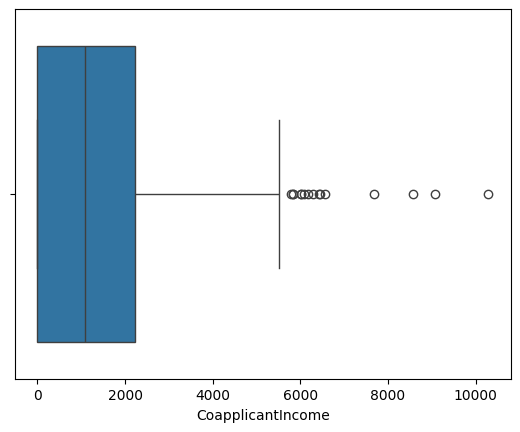

In [5]:
sns.boxplot(x="CoapplicantIncome", data=dataset)
plt.show()

Same starting point as `13_Outlier_Removal_IQR.ipynb` — the string of outlier dots past the right whisker.

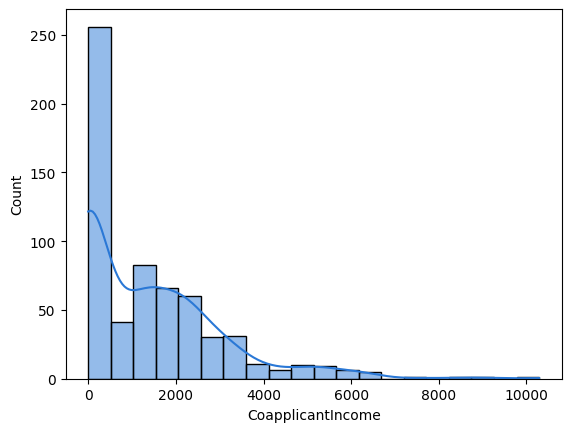

In [6]:
sns.histplot(dataset["CoapplicantIncome"], kde=True, color="#2a78d6")
plt.show()

(Fixed from the original `sns.distplot(...)` — same deprecation `12_Outlier.ipynb`
already flagged; `sns.histplot(..., kde=True)` is the current equivalent.)
A long right tail — the same skew that made IQR and Z-score disagree on
`ApplicantIncome` in `12_Outlier.ipynb` Section 5 is present here too.

## 1. Two Equivalent Ways to Apply the Threshold

**Method 1 — mean ± 3×std, as explicit bounds** (same shape as `13`'s
`min_range`/`max_range`, just built from `mean`/`std` instead of `Q1`/`Q3`).

In [7]:
min_range = dataset["CoapplicantIncome"].mean() - (3*dataset["CoapplicantIncome"].std())
max_range = dataset["CoapplicantIncome"].mean() + (3*dataset["CoapplicantIncome"].std())
min_range, max_range

(np.float64(-3450.2033416842687), np.float64(6220.358681490095))

`min_range` is negative again (`-3450.2`) — same reasoning as `13`:
`CoapplicantIncome` can never be negative, so only `max_range` (`6220.4`)
can ever actually filter anything out. Confirmed by shape next.

In [8]:
new_data = dataset[dataset["CoapplicantIncome"]<=max_range]
new_data.shape

(610, 13)

`(618, 13) → (610, 13)` — 8 rows removed.

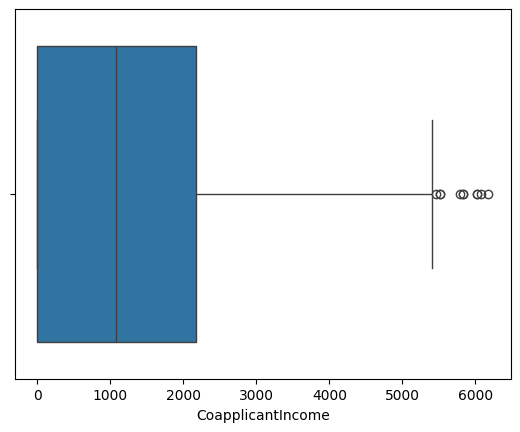

In [9]:
sns.boxplot(x="CoapplicantIncome" ,data= new_data)
plt.show()

Better than the original, but still has outlier dots visible — Z-score's
threshold is looser than IQR's turned out to be (`13`'s box plot after
removal was fully clean; this one isn't quite). Confirmed with numbers in
Section 4.

**Method 2 — an explicit `z_score` column.** Mathematically the same
threshold as Method 1, computed a different way: instead of converting the
threshold into raw income units (`max_range`), convert every income value
*into* σ units and compare against `3` directly.

In [10]:
z_score = (dataset["CoapplicantIncome"] - dataset["CoapplicantIncome"].mean()) / (dataset["CoapplicantIncome"].std())
z_score.head()

0   -0.226509
1   -0.114209
2   -0.198589
3   -0.859357
4    0.557107
Name: CoapplicantIncome, dtype: float64

Every value, re-expressed as "how many standard deviations from the
mean." Row 0's `CoapplicantIncome = 1020` becomes `z ≈ -0.23` — a bit below
average, nowhere near the `±3` cutoff.

In [11]:
(z_score > 3).sum()

np.int64(8)

**8** — same count Method 1's bounds produced. The two are the same
threshold, just measured in different units (raw income vs. σ). Worth
noting: only the positive side (`z_score > 3`) is checked here, not
`z_score.abs() > 3` — safe on this specific column because its minimum
z-score is `-0.86` (`CoapplicantIncome` is bounded at 0, so it can never
drift 3 std devs *below* the mean), but that's a property of *this* column,
not a general rule — a column that can genuinely go very negative (a
temperature, a profit/loss figure) would need the `.abs()` version, or it
would silently ignore real low-end outliers.

### The bug — be careful what "removal" actually removes

The original draft's next two steps were:

```python
dataset["z_score"] = z_score
dataset[dataset["z_score"] < 3]
```

That **writes `z_score` onto `dataset` itself**, permanently, before
filtering. The filtered result — meant to be the "clean" data — still
carries that helper column (`14` columns instead of `13`). Two concrete
problems that causes:

1. If this "clean" dataset gets combined with `13`'s IQR-cleaned dataset
   (or fed into a model), the column counts won't match, or worse, a model
   would silently train on a feature that's *literally computed from the
   target column's own outlier-ness* — a diagnostic column masquerading as
   real data.
2. `dataset` — the variable every earlier cell in *this notebook* also
   refers to — is now permanently mutated. Any cell above this one, re-run
   after this point, sees a `dataset` with an extra column it didn't expect.

**The fix:** keep `z_score` as its own standalone `Series` (already true
above — it was never attached to `dataset`), filter `dataset` directly
against it, and never assign it back:

In [12]:
z_cleaned = dataset[z_score.abs() < 3]
z_cleaned.shape

(610, 13)

`(610, 13)` — 13 columns, not 14: no leaked `z_score` column, and `dataset`
itself was never touched. Confirmed explicitly:

In [13]:
"z_score" in z_cleaned.columns, "z_score" in dataset.columns

(False, False)

`(False, False)` — clean on both counts. All three approaches (Method 1's bounds, Method 2's `z_score > 3` count, and this fixed filter) agree on **610 rows**, verified next.

In [14]:
new_data.shape[0] == z_cleaned.shape[0] == (618 - (z_score > 3).sum())

np.True_

`True` — same answer, three ways of getting there.

## 2. Visualizing the Z-Score Removal

Same before/after pair `13_Outlier_Removal_IQR.ipynb` used, on the
Z-score-cleaned data this time, plus one new chart specific to Z-score:
the σ-distances themselves.

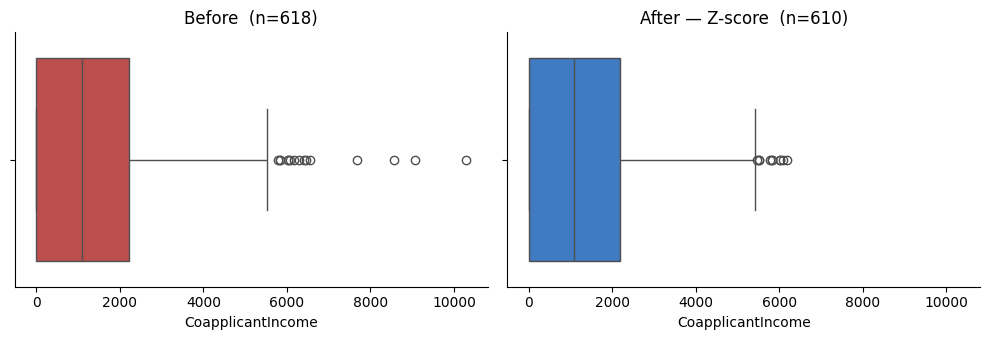

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True)
sns.boxplot(x="CoapplicantIncome", data=dataset, color="#d03b3b", ax=axes[0])
axes[0].set_title(f"Before  (n={dataset.shape[0]})")
sns.boxplot(x="CoapplicantIncome", data=z_cleaned, color="#2a78d6", ax=axes[1])
axes[1].set_title(f"After — Z-score  (n={z_cleaned.shape[0]})")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Visualization 1.** Fewer outlier dots than "before," but — unlike `13`'s
IQR version — not completely clean. That's expected now, not a mistake:
Section 4 shows exactly which points these are and why Z-score leaves them
behind.

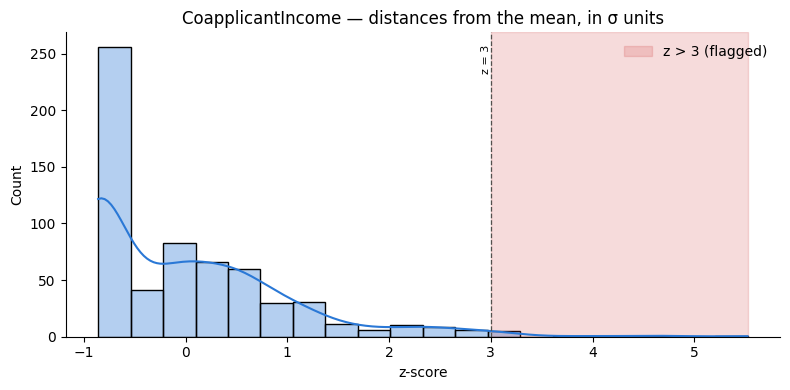

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(z_score, kde=True, color="#2a78d6", alpha=0.35, ax=ax)
ax.axvspan(3, z_score.max(), color="#d03b3b", alpha=0.18, label="z > 3 (flagged)")
ax.axvline(3, color="#52514e", linestyle="--", linewidth=0.9)
ax.text(3, ax.get_ylim()[1]*0.96, "z = 3", rotation=90, va="top", ha="right", fontsize=8)
ax.set_title("CoapplicantIncome — distances from the mean, in σ units")
ax.set_xlabel("z-score")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Visualization 2 — new, Z-score-specific.** Same shape as `12_Outlier.ipynb`'s
distribution chart, but the x-axis is now `z_score` instead of raw income —
this *is* the whiteboard's `σ` axis, with actual data plotted on it instead
of a theoretical normal curve. The 8 points past `z = 3` are the red region;
notice the curve is still right-skewed even in σ units — a truly normal
column would look symmetric here.

## 3. IQR vs. Z-Score, Head-to-Head, Same Column

`13`'s IQR bound for this exact column was **`5544.4`**; Z-score's is
**`6220.4`** — a real gap, not just rounding. Everything between those two
numbers is flagged as an outlier by IQR but treated as normal by Z-score.

In [17]:
q1 = dataset["CoapplicantIncome"].quantile(0.25)
q3 = dataset["CoapplicantIncome"].quantile(0.75)
iqr_bound = q3 + 1.5 * (q3 - q1)

iqr_flagged = dataset["CoapplicantIncome"] > iqr_bound
z_flagged = z_score > 3

print(f"IQR bound:      {iqr_bound:.1f}   ->  {iqr_flagged.sum()} rows flagged")
print(f"Z-score bound:  {max_range:.1f}   ->  {z_flagged.sum()} rows flagged")
print(f"Flagged by both:            {(iqr_flagged & z_flagged).sum()}")
print(f"Flagged by IQR, missed by Z-score: {(iqr_flagged & ~z_flagged).sum()}")

IQR bound:      5544.4   ->  15 rows flagged
Z-score bound:  6220.4   ->  8 rows flagged
Flagged by both:            8
Flagged by IQR, missed by Z-score: 7


**15 vs. 8.** All 8 of Z-score's outliers are also in IQR's 15 — Z-score
isn't wrong, it's just **more conservative**, missing 7 rows IQR catches.

In [18]:
dataset.loc[iqr_flagged & ~z_flagged, ["CoapplicantIncome"]].sort_values("CoapplicantIncome")

,CoapplicantIncome
133,5784
514,5831
232,5834
90,6016
384,6025
428,6074
576,6177


The 7 rows Z-score misses — all between `5544` (IQR's bound) and `6177`
(just under `6220`, Z-score's bound). These aren't borderline by accident:
they're genuinely unusual (comfortably above `Q3 = 2217.75`), but Z-score's
own threshold got pushed out past them.

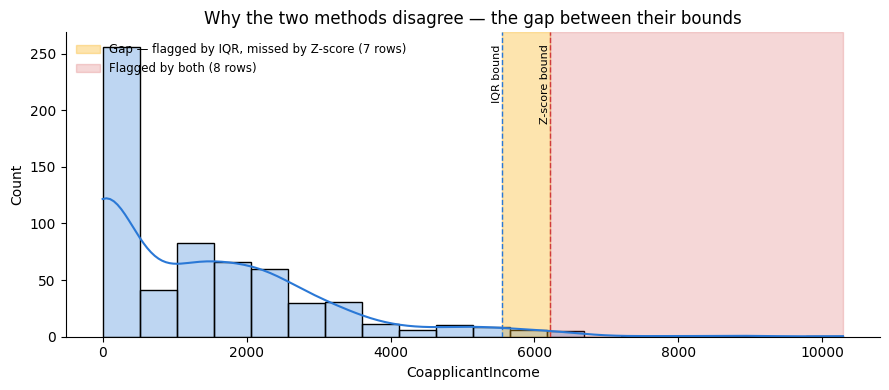

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(dataset["CoapplicantIncome"], kde=True, color="#2a78d6", alpha=0.3, ax=ax)
ax.axvspan(iqr_bound, max_range, color="#fab219", alpha=0.35, label=f"Gap — flagged by IQR, missed by Z-score ({(iqr_flagged & ~z_flagged).sum()} rows)")
ax.axvspan(max_range, dataset["CoapplicantIncome"].max(), color="#d03b3b", alpha=0.2, label=f"Flagged by both ({(iqr_flagged & z_flagged).sum()} rows)")
ax.axvline(iqr_bound, color="#2a78d6", linestyle="--", linewidth=1)
ax.axvline(max_range, color="#d03b3b", linestyle="--", linewidth=1)
ax.text(iqr_bound, ax.get_ylim()[1]*0.96, "IQR bound", rotation=90, va="top", ha="right", fontsize=8)
ax.text(max_range, ax.get_ylim()[1]*0.96, "Z-score bound", rotation=90, va="top", ha="right", fontsize=8)
ax.set_title("Why the two methods disagree — the gap between their bounds")
ax.legend(frameon=False, fontsize=8.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Visualization 3 — the disagreement, made visual.** The amber "warning"
band is the 7 rows IQR flags that Z-score's own bound sits past — not
because those points aren't unusual, but because Z-score's bound is built
from `mean` and `std`, and `12_Outlier.ipynb` Section 1 already proved both
of those get dragged outward by extreme values. `CoapplicantIncome`'s
maximum (`10288`, nearly 5x the mean) is doing exactly that here: it
inflates `std`, which widens `mean + 3×std`, which is precisely why the
amber band exists. **Z-score's threshold is computed from the same outliers
it's trying to catch** — a mild circularity IQR avoids by using percentiles
(`Q1`/`Q3`), which barely move when a handful of extreme values get more
extreme. This is the same story `12_Outlier.ipynb` Section 5 told on
`ApplicantIncome` (21 vs. 8), now confirmed on a second column with the
exact rows named.

## 4. The Final, Correctly-Cleaned Dataset

`z_cleaned` from Section 1 is already the right result — computed without
mutating `dataset`, with no leaked `z_score` column. Side by side with
`13`'s IQR-cleaned shape:

In [20]:
print("Original:            ", dataset.shape)
print("IQR-cleaned (13):     ", (dataset[dataset["CoapplicantIncome"] <= iqr_bound]).shape)
print("Z-score-cleaned (14): ", z_cleaned.shape)

Original:             (618, 13)
IQR-cleaned (13):      (603, 13)
Z-score-cleaned (14):  (610, 13)


`(618, 13) → (603, 13)` for IQR, `→ (610, 13)` for Z-score — IQR removes
more, and Section 3 showed exactly why: it isn't fooled by the same
outliers it's measuring against. **For a skewed real-world column like
this one, IQR is the more trustworthy default; Z-score stays simpler and
perfectly fine on data that's actually close to normal** — the same
conclusion `12_Outlier.ipynb` reached, now backed by a dedicated,
bug-fixed, head-to-head run on `CoapplicantIncome`.